<a href="https://colab.research.google.com/github/rodrigologin0-cpu/Rodrigo-de-Souza-Lima/blob/main/TCN_MPC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# TCN-NARX MULTI-HORIZONTE DIRETA
# Previsão de PV em h = 1, 5 e 10
# Entradas: PV | MV | Distúrbio Porta | Demanda térmica
# Google Colab
# ============================================================

!pip -q install openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import time
import warnings

from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.layers import (
    Input, Conv1D, Dense, Dropout, Add, LayerNormalization,
    Lambda, Flatten, Concatenate
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings("ignore")

In [69]:
# ============================================================
# 1) CONFIGURAÇÃO DO USUÁRIO
# ============================================================

USAR_UPLOAD = True
ARQUIVO_EXCEL = "/content/seu_dataset.xlsx"

if USAR_UPLOAD:
    from google.colab import files
    uploaded = files.upload()
    ARQUIVO_EXCEL = list(uploaded.keys())[0]

# ------------------------------------------------------------
# Ajuste os nomes das colunas aqui
# ------------------------------------------------------------

COL_PV = "PV"
COL_MV = "PCV"
COL_PORTA = "D"
COL_DEMANDA = "G"

COL_SP = None      # se não tiver SP, coloque None
SP_FIXO = 1.0      # usado apenas se COL_SP = None

# Tempo de amostragem
# Se for 0,4 ms: 0.0004
# Se for 0,4 s: 0.4
TS_AMOSTRAGEM_S = 0.4

# Horizontes desejados
HORIZONTES = [10, 20, 30]
H_MAX = max(HORIZONTES)

# Janela passada usada pela TCN
WINDOW = 10

# Divisão temporal
FRAC_TREINO = 0.70
FRAC_VALIDACAO = 0.15

# Configuração da TCN
FILTROS = 16
KERNEL_SIZE = 3
DILATACOES = [1, 2, 4, 8]
DROPOUT = 0.05

EPOCHS = 50
BATCH_SIZE = 64
LEARNING_RATE = 0.001


Saving Pressão_Interna.xlsx to Pressão_Interna (4).xlsx


In [70]:
# ============================================================
# 2) CARREGAMENTO DOS DADOS - VERSÃO INCREMENTAL ΔPV / ΔMV
# ============================================================

df_original = pd.read_excel(ARQUIVO_EXCEL)
df_original.columns = [str(c).strip() for c in df_original.columns]

print("Colunas encontradas:")
print(df_original.columns.tolist())

# ------------------------------------------------------------
# Nomes reais das colunas do seu dataset
# ------------------------------------------------------------

COL_PV = "PV"        # pressão / variável controlada
COL_MV = "PCV"       # MV / posição da PCV ou damper
COL_PORTA = "D"      # distúrbio porta
COL_DEMANDA = "G"    # carga térmica / demanda térmica

# Caso não exista coluna de SP no dataset
# Se existir, coloque o nome correto, por exemplo: COL_SP = "SP"
COL_SP = None
SP_FIXO = 1.0

if COL_SP is None:
    df_original["SP_FIXO"] = SP_FIXO
    COL_SP = "SP_FIXO"

# ------------------------------------------------------------
# Verificação das colunas básicas
# ------------------------------------------------------------

colunas_base = [
    COL_PV,
    COL_MV,
    COL_PORTA,
    COL_DEMANDA,
    COL_SP
]

for c in colunas_base:
    if c not in df_original.columns:
        raise ValueError(f"Coluna não encontrada: {c}")

# ------------------------------------------------------------
# Conversão para numérico antes de calcular deltas
# ------------------------------------------------------------

df_original[colunas_base] = df_original[colunas_base].apply(
    pd.to_numeric,
    errors="coerce"
)

# ------------------------------------------------------------
# Criação das variáveis incrementais
# ------------------------------------------------------------

DELTA_MV = "DELTA_MV"
DELTA_PV = "DELTA_PV"

df_original[DELTA_MV] = df_original[COL_MV].diff().fillna(0.0)
df_original[DELTA_PV] = df_original[COL_PV].diff().fillna(0.0)

# ------------------------------------------------------------
# Colunas usadas pela TCN incremental
# ------------------------------------------------------------

COL_PAST = [
    COL_PV,
    COL_MV,
    DELTA_MV,
    COL_PORTA,
    COL_DEMANDA
]

COL_FUTURE = [
    COL_MV,
    DELTA_MV,
    COL_PORTA,
    COL_DEMANDA
]

colunas_necessarias = list(set(COL_PAST + COL_FUTURE + [COL_SP]))

for c in colunas_necessarias:
    if c not in df_original.columns:
        raise ValueError(f"Coluna não encontrada: {c}")

# ------------------------------------------------------------
# DataFrame final
# ------------------------------------------------------------

df = df_original[colunas_necessarias].copy()
df = df.apply(pd.to_numeric, errors="coerce")
df = df.dropna().reset_index(drop=True)

print("\nAmostras após limpeza:", len(df))
print("Colunas usadas no modelo:")
print(df.columns.tolist())

display(df.head())

print("\nHorizontes físicos:")
for h in HORIZONTES:
    print(f"h={h}: {h * TS_AMOSTRAGEM_S:.2f} s")

Colunas encontradas:
['PV', 'G', 'D', 'PCV']

Amostras após limpeza: 156588
Colunas usadas no modelo:
['SP_FIXO', 'PCV', 'DELTA_MV', 'D', 'PV', 'G']


,SP_FIXO,PCV,DELTA_MV,D,PV,G
0,1.0,65.8760,0.0000,26.3749,1.31533,83.9030
1,1.0,65.7219,-0.1541,26.3723,1.31493,83.9018
2,1.0,65.6510,-0.0709,26.3955,1.31171,83.9010
3,1.0,65.6002,-0.0508,27.4639,1.30811,83.9003
4,1.0,65.5639,-0.0363,27.4493,1.30315,83.8998



Horizontes físicos:
h=10: 4.00 s
h=20: 8.00 s
h=30: 12.00 s


In [71]:
# ============================================================
# 3) CRIAÇÃO DAS JANELAS MULTI-HORIZONTE
# ============================================================

def criar_dataset_multihorizonte(df, window, horizontes):
    """
    Entrada 1: janela passada [PV, MV, PORTA, DEMANDA]
    Entrada 2: plano futuro [MV, PORTA, DEMANDA] de k+1 até k+H_MAX
    Saída: PV futura em h = 1, 5, 10
    """

    X_past = []
    X_future = []
    y = []
    indices_k = []

    hmax = max(horizontes)

    dados_past = df[COL_PAST].values.astype(float)
    dados_future = df[COL_FUTURE].values.astype(float)
    dados_pv = df[COL_PV].values.astype(float)

    for k in range(window - 1, len(df) - hmax):
        janela_passada = dados_past[k - window + 1:k + 1, :]

        plano_futuro = dados_future[k + 1:k + hmax + 1, :]

        pv_atual = dados_pv[k]
        alvo = [dados_pv[k + h] - pv_atual for h in horizontes]

        X_past.append(janela_passada)
        X_future.append(plano_futuro)
        y.append(alvo)
        indices_k.append(k)

    return (
        np.array(X_past),
        np.array(X_future),
        np.array(y),
        np.array(indices_k)
    )

X_past_raw, X_future_raw, y_raw, idx_k = criar_dataset_multihorizonte(
    df=df,
    window=WINDOW,
    horizontes=HORIZONTES
)

print("\nShapes brutos:")
print("X_past:", X_past_raw.shape)
print("X_future:", X_future_raw.shape)
print("y:", y_raw.shape)

n_total = len(y_raw)
idx_train_end = int(FRAC_TREINO * n_total)
idx_val_end = int((FRAC_TREINO + FRAC_VALIDACAO) * n_total)

X_past_train_raw = X_past_raw[:idx_train_end]
X_past_val_raw = X_past_raw[idx_train_end:idx_val_end]
X_past_test_raw = X_past_raw[idx_val_end:]

X_future_train_raw = X_future_raw[:idx_train_end]
X_future_val_raw = X_future_raw[idx_train_end:idx_val_end]
X_future_test_raw = X_future_raw[idx_val_end:]

y_train_raw = y_raw[:idx_train_end]
y_val_raw = y_raw[idx_train_end:idx_val_end]
y_test_raw = y_raw[idx_val_end:]

idx_test = idx_k[idx_val_end:]



Shapes brutos:
X_past: (156549, 10, 5)
X_future: (156549, 30, 4)
y: (156549, 3)


In [72]:
# ============================================================
# 4) NORMALIZAÇÃO
# ============================================================

scaler_past = StandardScaler()
scaler_future = StandardScaler()
scaler_y = StandardScaler()

n_past_features = X_past_raw.shape[2]
n_future_features = X_future_raw.shape[2]
n_outputs = len(HORIZONTES)

scaler_past.fit(X_past_train_raw.reshape(-1, n_past_features))
scaler_future.fit(X_future_train_raw.reshape(-1, n_future_features))
scaler_y.fit(y_train_raw)

def transformar_past(X):
    shape = X.shape
    return scaler_past.transform(X.reshape(-1, shape[2])).reshape(shape)

def transformar_future(X):
    shape = X.shape
    return scaler_future.transform(X.reshape(-1, shape[2])).reshape(shape)

X_past_train = transformar_past(X_past_train_raw)
X_past_val = transformar_past(X_past_val_raw)
X_past_test = transformar_past(X_past_test_raw)

X_future_train = transformar_future(X_future_train_raw)
X_future_val = transformar_future(X_future_val_raw)
X_future_test = transformar_future(X_future_test_raw)

y_train = scaler_y.transform(y_train_raw)
y_val = scaler_y.transform(y_val_raw)
y_test = scaler_y.transform(y_test_raw)


In [73]:
# ============================================================
# 5) MODELO TCN-NARX MULTI-HORIZONTE
# ============================================================

def bloco_tcn(x, filtros, kernel_size, dilatacao, dropout):
    entrada = x

    x = Conv1D(
        filters=filtros,
        kernel_size=kernel_size,
        padding="causal",
        dilation_rate=dilatacao,
        activation="relu"
    )(x)

    x = Dropout(dropout)(x)

    x = Conv1D(
        filters=filtros,
        kernel_size=kernel_size,
        padding="causal",
        dilation_rate=dilatacao,
        activation="relu"
    )(x)

    if entrada.shape[-1] != filtros:
        entrada = Conv1D(
            filters=filtros,
            kernel_size=1,
            padding="same"
        )(entrada)

    x = Add()([x, entrada])
    x = LayerNormalization()(x)

    return x


def construir_tcn_multihorizonte():
    entrada_past = Input(shape=(WINDOW, n_past_features), name="janela_passada")
    entrada_future = Input(shape=(H_MAX, n_future_features), name="plano_futuro")

    x = entrada_past

    for d in DILATACOES:
        x = bloco_tcn(
            x=x,
            filtros=FILTROS,
            kernel_size=KERNEL_SIZE,
            dilatacao=d,
            dropout=DROPOUT
        )

    # representa o estado dinâmico atual
    x = Lambda(lambda z: z[:, -1, :], name="estado_atual_tcn")(x)

    # representa o plano futuro de MV, porta e demanda
    f = Flatten(name="future_flatten")(entrada_future)
    f = Dense(32, activation="relu", name="future_dense")(f)

    z = Concatenate(name="concat_estado_futuro")([x, f])
    z = Dense(64, activation="relu")(z)
    z = Dropout(DROPOUT)(z)
    z = Dense(32, activation="relu")(z)

    saida = Dense(n_outputs, activation="linear", name="pv_horizontes")(z)

    model = Model(
        inputs=[entrada_past, entrada_future],
        outputs=saida
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="mse",
        metrics=["mae"]
    )

    return model

modelo_tcn = construir_tcn_multihorizonte()
modelo_tcn.summary()

early = EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-5
)

hist = modelo_tcn.fit(
    [X_past_train, X_future_train],
    y_train,
    validation_data=([X_past_val, X_future_val], y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early, reduce_lr],
    verbose=1
)


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ janela_passada      │ (None, 10, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_47 (Conv1D)  │ (None, 10, 16)    │        256 │ janela_passada[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_26          │ (None, 10, 16)    │          0 │ conv1d_47[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_48 (Conv1D)  │ (None, 10, 16)    │        784 │ dropout_26[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_49 (Conv1D)  │ (None, 10, 16)    │         96 │ janela_passada[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_21 (Add)        │ (None, 10, 16)    │          0 │ conv1d_48[0][0],  │
│                     │                   │            │ conv1d_49[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 16)    │         32 │ add_21[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_50 (Conv1D)  │ (None, 10, 16)    │        784 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_27          │ (None, 10, 16)    │          0 │ conv1d_50[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_51 (Conv1D)  │ (None, 10, 16)    │        784 │ dropout_27[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_22 (Add)        │ (None, 10, 16)    │          0 │ conv1d_51[0][0],  │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 16)    │         32 │ add_22[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_52 (Conv1D)  │ (None, 10, 16)    │        784 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_28          │ (None, 10, 16)    │          0 │ conv1d_52[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_53 (Conv1D)  │ (None, 10, 16)    │        784 │ dropout_28[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_23 (Add)        │ (None, 10, 16)    │          0 │ conv1d_53[0][0],  │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 16)    │         32 │ add_23[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_54 (Conv1D)  │ (None, 10, 16)    │        784 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_29          │ (None, 10, 16)    │          0 │ conv1d_54[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 15,155 (59.20 KB)

 Trainable params: 15,155 (59.20 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step - loss: 0.2068 - mae: 0.3304 - val_loss: 0.1909 - val_mae: 0.3009 - learning_rate: 0.0010
Epoch 2/50
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.1063 - mae: 0.2353 - val_loss: 0.1515 - val_mae: 0.2676 - learning_rate: 0.0010
Epoch 3/50
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0830 - mae: 0.2072 - val_loss: 0.1385 - val_mae: 0.2587 - learning_rate: 0.0010
Epoch 4/50
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0705 - mae: 0.1903 - val_loss: 0.1143 - val_mae: 0.2243 - learning_rate: 0.0010
Epoch 5/50
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0628 - mae: 0.1792 - val_loss: 0.1162 - val_mae: 0.2297 - learning_rate: 0.0010
Epoch 6/50
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0575 - mae: 0.1710 - val_loss: 0.0978 - val_mae: 0.2087 - learning_rate: 0.0010
Epoch 7/50
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0529 - mae: 0.1639 - val_loss: 0.1032 - val_mae: 0.2094 - learnin


Desempenho da TCN-NARX incremental multi-horizonte no teste:
Modelo treinado para prever ΔPV(k+h) = PV(k+h) - PV(k)


,horizonte_h,tempo_s,MAE_DeltaPV,RMSE_DeltaPV,MAE_PV_reconstruida,RMSE_PV_reconstruida
0,10,4.0,0.028544,0.041215,0.028544,0.041215
1,20,8.0,0.048883,0.070411,0.048883,0.070411
2,30,12.0,0.065790,0.093706,0.065790,0.093706


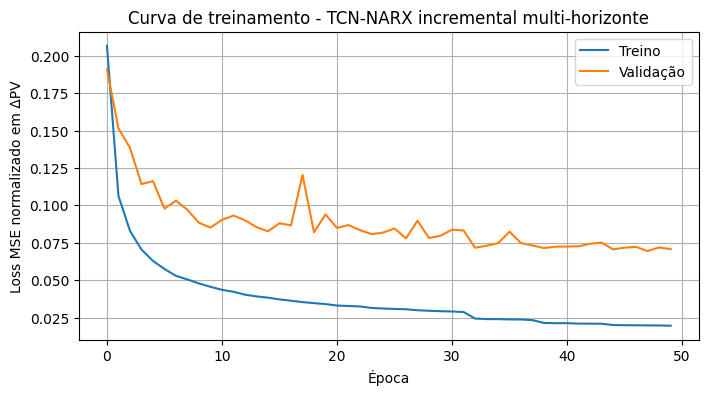

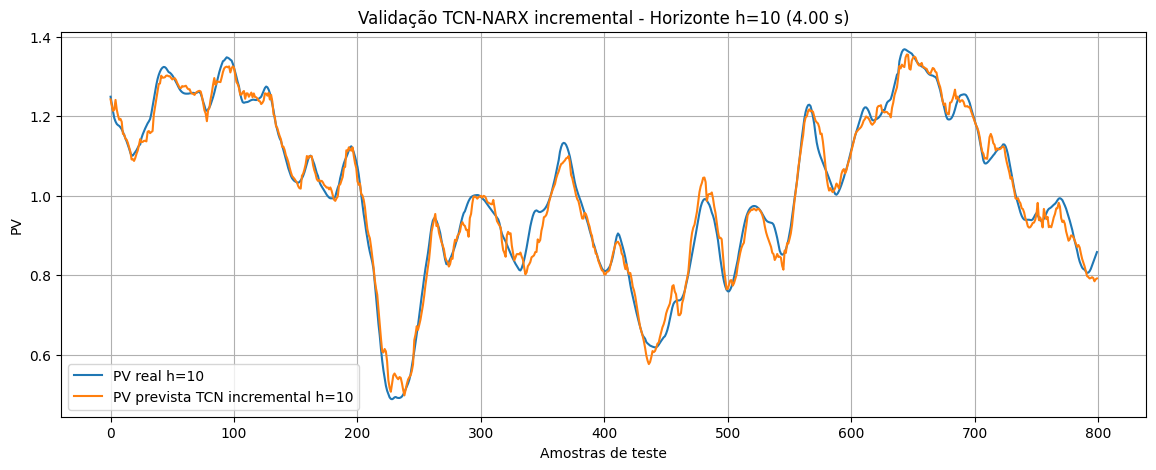

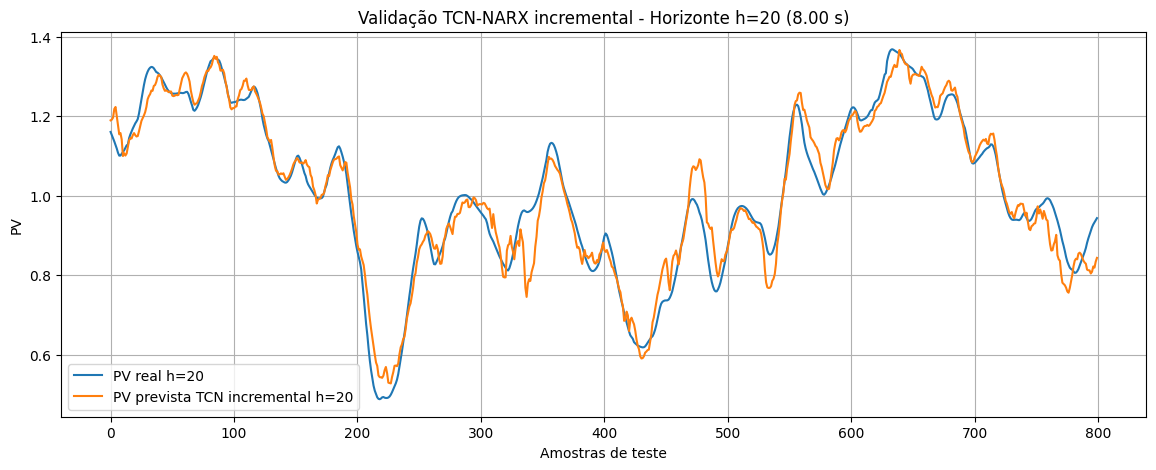

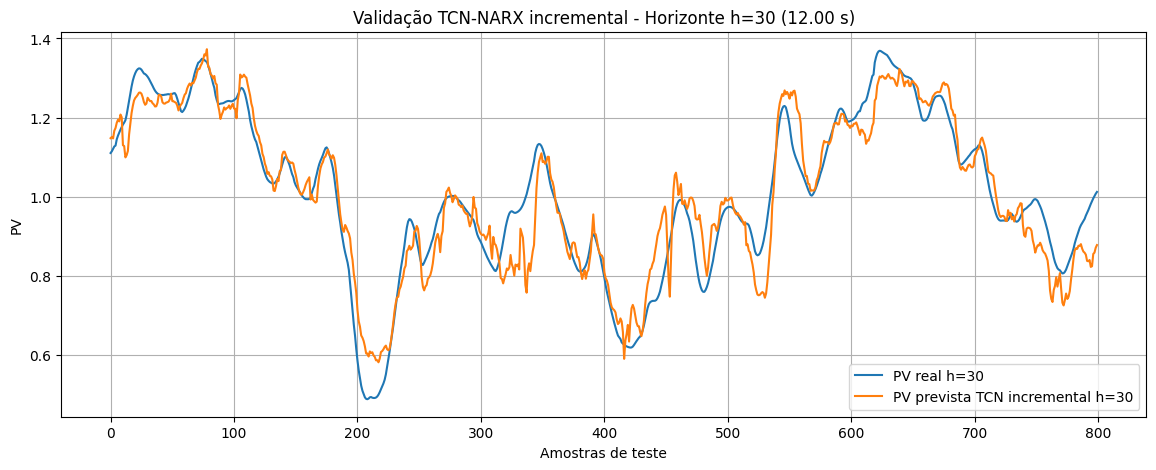

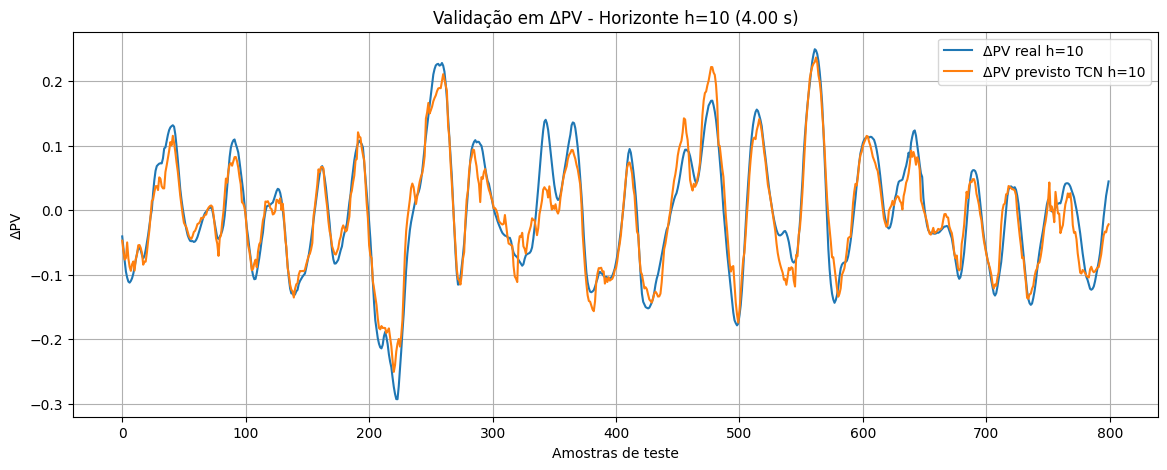

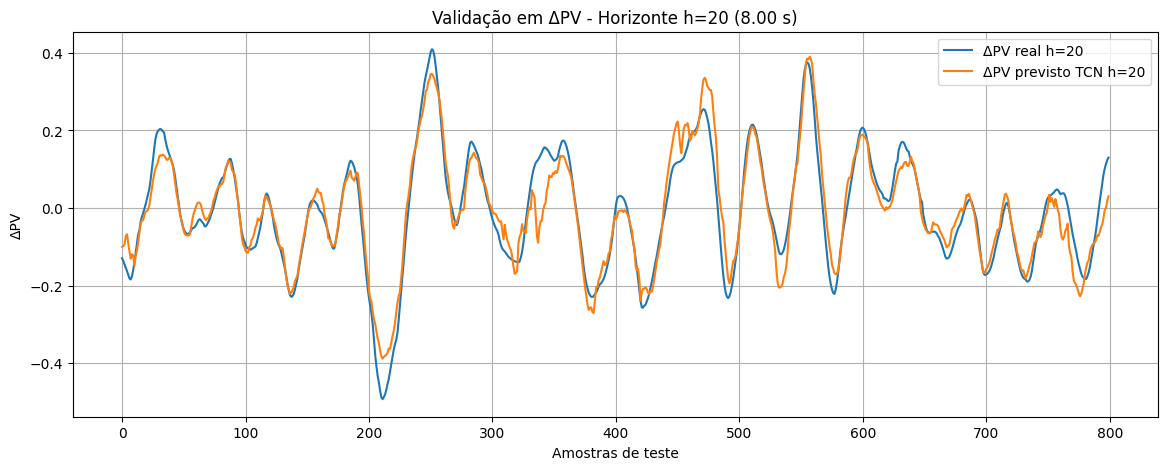

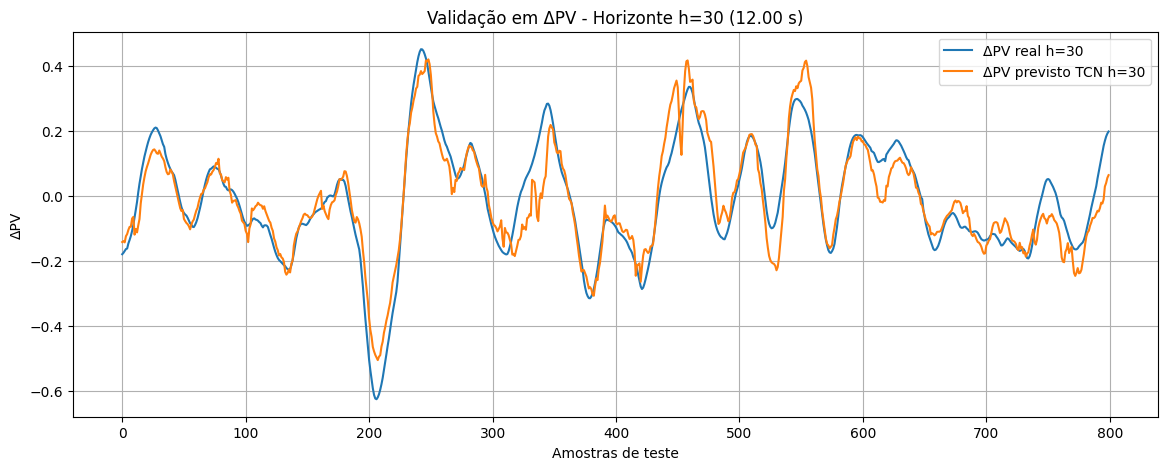


Comparação pontual em um trecho de teste:
h=10 | tempo=4.00s | PV atual=1.2900 | PV real=1.2493 | PV prevista=1.2427 | ΔPV real=-0.0406 | ΔPV previsto=-0.0473 | erro PV=-0.0066
h=20 | tempo=8.00s | PV atual=1.2900 | PV real=1.1606 | PV prevista=1.1898 | ΔPV real=-0.1294 | ΔPV previsto=-0.1001 | erro PV=+0.0292
h=30 | tempo=12.00s | PV atual=1.2900 | PV real=1.1103 | PV prevista=1.1478 | ΔPV real=-0.1797 | ΔPV previsto=-0.1422 | erro PV=+0.0375


In [74]:
# ============================================================
# 6) AVALIAÇÃO DO MODELO - VERSÃO INCREMENTAL ΔPV
# ============================================================

# A rede prevê DELTA_PV normalizado
y_pred_test_norm = modelo_tcn.predict(
    [X_past_test, X_future_test],
    verbose=0
)

# Converte DELTA_PV previsto para unidade real
delta_pv_pred_test = scaler_y.inverse_transform(y_pred_test_norm)

# DELTA_PV real em unidade real
delta_pv_real_test = y_test_raw

# PV atual de cada amostra de teste
# idx_test contém o índice k correspondente a cada janela de teste
pv_atual_test = df.loc[idx_test, COL_PV].values.astype(float).reshape(-1, 1)

# Reconstrói PV futura real e prevista
pv_pred_test = pv_atual_test + delta_pv_pred_test
pv_real_test = pv_atual_test + delta_pv_real_test

print("\nDesempenho da TCN-NARX incremental multi-horizonte no teste:")
print("Modelo treinado para prever ΔPV(k+h) = PV(k+h) - PV(k)")

metricas = []

for i, h in enumerate(HORIZONTES):

    # Métricas em ΔPV
    mae_delta = mean_absolute_error(
        delta_pv_real_test[:, i],
        delta_pv_pred_test[:, i]
    )

    rmse_delta = np.sqrt(mean_squared_error(
        delta_pv_real_test[:, i],
        delta_pv_pred_test[:, i]
    ))

    # Métricas em PV reconstruída
    mae_pv = mean_absolute_error(
        pv_real_test[:, i],
        pv_pred_test[:, i]
    )

    rmse_pv = np.sqrt(mean_squared_error(
        pv_real_test[:, i],
        pv_pred_test[:, i]
    ))

    metricas.append({
        "horizonte_h": h,
        "tempo_s": h * TS_AMOSTRAGEM_S,
        "MAE_DeltaPV": mae_delta,
        "RMSE_DeltaPV": rmse_delta,
        "MAE_PV_reconstruida": mae_pv,
        "RMSE_PV_reconstruida": rmse_pv
    })

df_metricas = pd.DataFrame(metricas)
display(df_metricas)

# ============================================================
# Curva de treinamento
# ============================================================

plt.figure(figsize=(8, 4))
plt.plot(hist.history["loss"], label="Treino")
plt.plot(hist.history["val_loss"], label="Validação")
plt.title("Curva de treinamento - TCN-NARX incremental multi-horizonte")
plt.xlabel("Época")
plt.ylabel("Loss MSE normalizado em ΔPV")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# Gráficos por horizonte - PV reconstruída
# ============================================================

N_PLOT = min(800, len(pv_real_test))

for i, h in enumerate(HORIZONTES):
    plt.figure(figsize=(14, 5))
    plt.plot(
        pv_real_test[:N_PLOT, i],
        label=f"PV real h={h}"
    )
    plt.plot(
        pv_pred_test[:N_PLOT, i],
        label=f"PV prevista TCN incremental h={h}"
    )
    plt.title(
        f"Validação TCN-NARX incremental - Horizonte h={h} "
        f"({h * TS_AMOSTRAGEM_S:.2f} s)"
    )
    plt.xlabel("Amostras de teste")
    plt.ylabel(COL_PV)
    plt.legend()
    plt.grid(True)
    plt.show()

# ============================================================
# Gráficos por horizonte - ΔPV
# ============================================================

for i, h in enumerate(HORIZONTES):
    plt.figure(figsize=(14, 5))
    plt.plot(
        delta_pv_real_test[:N_PLOT, i],
        label=f"ΔPV real h={h}"
    )
    plt.plot(
        delta_pv_pred_test[:N_PLOT, i],
        label=f"ΔPV previsto TCN h={h}"
    )
    plt.title(
        f"Validação em ΔPV - Horizonte h={h} "
        f"({h * TS_AMOSTRAGEM_S:.2f} s)"
    )
    plt.xlabel("Amostras de teste")
    plt.ylabel("ΔPV")
    plt.legend()
    plt.grid(True)
    plt.show()

# ============================================================
# Comparação pontual em um trecho de teste
# ============================================================

print("\nComparação pontual em um trecho de teste:")

idx_ponto = 0

for i, h in enumerate(HORIZONTES):
    print(
        f"h={h:2d} | tempo={h * TS_AMOSTRAGEM_S:.2f}s | "
        f"PV atual={pv_atual_test[idx_ponto, 0]:.4f} | "
        f"PV real={pv_real_test[idx_ponto, i]:.4f} | "
        f"PV prevista={pv_pred_test[idx_ponto, i]:.4f} | "
        f"ΔPV real={delta_pv_real_test[idx_ponto, i]:+.4f} | "
        f"ΔPV previsto={delta_pv_pred_test[idx_ponto, i]:+.4f} | "
        f"erro PV={pv_pred_test[idx_ponto, i] - pv_real_test[idx_ponto, i]:+.4f}"
    )

In [75]:
# ============================================================
# 7) TESTE DE SENSIBILIDADE DA MV
# ============================================================

idx_mv_future = COL_FUTURE.index(COL_MV)

def prever_tcn_multihorizonte(janela_past_raw, plano_future_raw):
    """
    Retorna PV prevista para h = 1, 5 e 10 em unidades reais.
    """

    Xp = transformar_past(janela_past_raw.reshape(1, WINDOW, n_past_features))
    Xf = transformar_future(plano_future_raw.reshape(1, H_MAX, n_future_features))

    y_norm = modelo_tcn([Xp, Xf], training=False).numpy()
    y_real = scaler_y.inverse_transform(y_norm)[0]

    return y_real

# ponto de teste
k_base = int(idx_test[0])

janela_past_debug = df.loc[
    k_base - WINDOW + 1:k_base,
    COL_PAST
].values.astype(float)

plano_future_debug = df.loc[
    k_base + 1:k_base + H_MAX,
    COL_FUTURE
].values.astype(float)

u_atual = float(df.loc[k_base, COL_MV])

print("\nTeste de sensibilidade da MV com TCN multi-horizonte")
print("u_atual =", u_atual)

for du in [-10, -5, 0, 5, 10]:
    plano_aux = plano_future_debug.copy()

    u_cand = u_atual + du

    # aplica MV futura constante candidata
    plano_aux[:, idx_mv_future] = u_cand

    y_prev = prever_tcn_multihorizonte(janela_past_debug, plano_aux)

    texto = f"du={du:+.1f} | u={u_cand:.2f}"
    for i, h in enumerate(HORIZONTES):
        texto += f" | PV h={h}: {y_prev[i]:.4f}"

    print(texto)



Teste de sensibilidade da MV com TCN multi-horizonte
u_atual = 30.4914
du=-10.0 | u=20.49 | PV h=10: -0.0763 | PV h=20: -0.1378 | PV h=30: -0.1703
du=-5.0 | u=25.49 | PV h=10: -0.0583 | PV h=20: -0.1149 | PV h=30: -0.1535
du=+0.0 | u=30.49 | PV h=10: -0.0456 | PV h=20: -0.0988 | PV h=30: -0.1420
du=+5.0 | u=35.49 | PV h=10: -0.0357 | PV h=20: -0.0870 | PV h=30: -0.1346
du=+10.0 | u=40.49 | PV h=10: -0.0261 | PV h=20: -0.0752 | PV h=30: -0.1273


In [76]:
# ============================================================
# TESTE DE SENSIBILIDADE DA PCV/MV - DEGRAU E MANTÉM
# ============================================================

idx_mv_future = COL_FUTURE.index(COL_MV)
idx_delta_mv_future = COL_FUTURE.index(DELTA_MV)

def prever_tcn_incremental_multihorizonte(janela_past_raw, plano_future_raw):
    Xp = transformar_past(
        janela_past_raw.reshape(1, WINDOW, n_past_features)
    )

    Xf = transformar_future(
        plano_future_raw.reshape(1, H_MAX, n_future_features)
    )

    delta_norm = modelo_tcn([Xp, Xf], training=False).numpy()
    delta_real = scaler_y.inverse_transform(delta_norm)[0]

    pv_atual = janela_past_raw[-1, COL_PAST.index(COL_PV)]
    pv_prevista = pv_atual + delta_real

    return delta_real, pv_prevista


k_base = int(idx_test[0])

janela_past_debug = df.loc[
    k_base - WINDOW + 1:k_base,
    COL_PAST
].values.astype(float)

plano_future_debug = df.loc[
    k_base + 1:k_base + H_MAX,
    COL_FUTURE
].values.astype(float)

u_atual = float(df.loc[k_base, COL_MV])

print("\nTeste de sensibilidade da PCV/MV com TCN incremental")
print("u_atual =", u_atual)

for du in [-10, -5, 0, 5, 10]:
    plano_aux = plano_future_debug.copy()

    u_cand = u_atual + du

    # Degrau de PCV: novo valor constante no horizonte
    plano_aux[:, idx_mv_future] = u_cand

    # ΔMV coerente com degrau: muda no primeiro passo, depois fica constante
    plano_aux[:, idx_delta_mv_future] = 0.0
    plano_aux[0, idx_delta_mv_future] = u_cand - u_atual

    delta_prev, pv_prev = prever_tcn_incremental_multihorizonte(
        janela_past_debug,
        plano_aux
    )

    texto = f"du={du:+.1f} | u={u_cand:.2f}"

    for i, h in enumerate(HORIZONTES):
        texto += (
            f" | ΔPV h={h}: {delta_prev[i]:+.4f}"
            f" | PV h={h}: {pv_prev[i]:.4f}"
        )

    print(texto)


Teste de sensibilidade da PCV/MV com TCN incremental
u_atual = 30.4914
du=-10.0 | u=20.49 | ΔPV h=10: -0.0875 | PV h=10: 1.2024 | ΔPV h=20: -0.1302 | PV h=20: 1.1597 | ΔPV h=30: -0.1131 | PV h=30: 1.1769
du=-5.0 | u=25.49 | ΔPV h=10: -0.0446 | PV h=10: 1.2453 | ΔPV h=20: -0.1329 | PV h=20: 1.1570 | ΔPV h=30: -0.1577 | PV h=30: 1.1322
du=+0.0 | u=30.49 | ΔPV h=10: -0.0196 | PV h=10: 1.2703 | ΔPV h=20: -0.1884 | PV h=20: 1.1016 | ΔPV h=30: -0.2984 | PV h=30: 0.9915
du=+5.0 | u=35.49 | ΔPV h=10: -0.0323 | PV h=10: 1.2577 | ΔPV h=20: -0.1768 | PV h=20: 1.1132 | ΔPV h=30: -0.3415 | PV h=30: 0.9485
du=+10.0 | u=40.49 | ΔPV h=10: -0.0520 | PV h=10: 1.2379 | ΔPV h=20: -0.1485 | PV h=20: 1.1414 | ΔPV h=30: -0.2903 | PV h=30: 0.9997


In [77]:
# ============================================================
# TESTE DE COERÊNCIA CAUSAL DA TCN INCREMENTAL EM VÁRIAS JANELAS
# Física esperada: PCV maior -> PV menor
# Logo: PV(du=+delta) - PV(du=-delta) deve ser negativo
# ============================================================

def avaliar_coerencia_causal_tcn(n_testes=100, delta_u=10.0):
    resultados = []

    indices = np.linspace(0, len(idx_test) - 1, n_testes).astype(int)

    idx_mv_future = COL_FUTURE.index(COL_MV)
    idx_delta_mv_future = COL_FUTURE.index(DELTA_MV)

    for ii in indices:
        k_base = int(idx_test[ii])

        if k_base - WINDOW + 1 < 0 or k_base + H_MAX >= len(df):
            continue

        janela_past = df.loc[
            k_base - WINDOW + 1:k_base,
            COL_PAST
        ].values.astype(float)

        plano_future = df.loc[
            k_base + 1:k_base + H_MAX,
            COL_FUTURE
        ].values.astype(float)

        u_atual = float(df.loc[k_base, COL_MV])

        # Cenário com PCV menor
        plano_menos = plano_future.copy()
        u_menos = u_atual - delta_u
        plano_menos[:, idx_mv_future] = u_menos
        plano_menos[:, idx_delta_mv_future] = 0.0
        plano_menos[0, idx_delta_mv_future] = u_menos - u_atual

        # Cenário com PCV maior
        plano_mais = plano_future.copy()
        u_mais = u_atual + delta_u
        plano_mais[:, idx_mv_future] = u_mais
        plano_mais[:, idx_delta_mv_future] = 0.0
        plano_mais[0, idx_delta_mv_future] = u_mais - u_atual

        delta_menos, pv_menos = prever_tcn_incremental_multihorizonte(
            janela_past,
            plano_menos
        )

        delta_mais, pv_mais = prever_tcn_incremental_multihorizonte(
            janela_past,
            plano_mais
        )

        linha = {
            "k": k_base,
            "u_atual": u_atual
        }

        for j, h in enumerate(HORIZONTES):
            diferenca = pv_mais[j] - pv_menos[j]

            linha[f"PV_menos_h{h}"] = pv_menos[j]
            linha[f"PV_mais_h{h}"] = pv_mais[j]
            linha[f"dif_h{h}"] = diferenca

            # Correto se PCV maior gera PV menor
            linha[f"sinal_correto_h{h}"] = diferenca < 0

        resultados.append(linha)

    df_coerencia = pd.DataFrame(resultados)

    print("\nResumo de coerência causal:")
    for h in HORIZONTES:
        perc = 100 * df_coerencia[f"sinal_correto_h{h}"].mean()
        media_dif = df_coerencia[f"dif_h{h}"].mean()

        print(
            f"h={h:2d} | "
            f"% sinal correto = {perc:.1f}% | "
            f"média PV(+du)-PV(-du) = {media_dif:+.5f}"
        )

    return df_coerencia

df_coerencia_tcn = avaliar_coerencia_causal_tcn(
    n_testes=100,
    delta_u=10.0
)

display(df_coerencia_tcn.head())


Resumo de coerência causal:
h=10 | % sinal correto = 20.0% | média PV(+du)-PV(-du) = +0.05013
h=20 | % sinal correto = 82.0% | média PV(+du)-PV(-du) = -0.06355
h=30 | % sinal correto = 86.0% | média PV(+du)-PV(-du) = -0.08026


,k,u_atual,PV_menos_h10,PV_mais_h10,dif_h10,sinal_correto_h10,PV_menos_h20,PV_mais_h20,dif_h20,sinal_correto_h20,PV_menos_h30,PV_mais_h30,dif_h30,sinal_correto_h30
0,133075,30.4914,1.202447,1.237940,0.035493,False,1.159715,1.141425,-0.018290,True,1.176902,0.999667,-0.177235,True
1,133312,30.9708,0.531951,0.536920,0.004969,False,0.616863,0.501061,-0.115802,True,0.648151,0.445018,-0.203134,True
2,133549,24.9351,0.635092,0.710111,0.075019,False,0.853029,0.793226,-0.059803,True,1.065108,1.049897,-0.015210,True
3,133786,40.7011,1.045289,1.041337,-0.003953,True,1.200461,1.062882,-0.137579,True,1.351179,1.231374,-0.119806,True
4,134023,36.9725,1.102923,1.099662,-0.003261,True,1.207777,1.055518,-0.152259,True,1.134962,1.059033,-0.075929,True


In [31]:

# ============================================================
# 8) COMPARAÇÃO REAL x PREVISTO EM UM PONTO ESPECÍFICO
# ============================================================

print("\nComparação pontual em um trecho de teste:")

y_prev_ponto = prever_tcn_multihorizonte(
    janela_past_debug,
    plano_future_debug
)

for i, h in enumerate(HORIZONTES):
    y_real = float(df.loc[k_base + h, COL_PV])
    y_prev = y_prev_ponto[i]

    print(
        f"h={h:2d} | tempo={h * TS_AMOSTRAGEM_S:.6f}s | "
        f"PV real={y_real:.4f} | PV prevista={y_prev:.4f} | "
        f"erro={y_prev - y_real:+.4f}"
    )



Comparação pontual em um trecho de teste:
h= 1 | tempo=0.400000s | PV real=1.1606 | PV prevista=-0.0039 | erro=-1.1645
h= 5 | tempo=2.000000s | PV real=1.1281 | PV prevista=-0.0361 | erro=-1.1641
h=10 | tempo=4.000000s | PV real=1.1057 | PV prevista=-0.0633 | erro=-1.1689


In [ ]:
# ============================================================
# MPC COM TCN INCREMENTAL MULTI-HORIZONTE
# Usando somente H = 10 como horizonte de controle
# Requer modelo_tcn já treinado
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time


In [78]:

# ============================================================
# 1) CONFIGURAÇÃO DO MPC
# ============================================================

H_CONTROLE = 30              # usar h=10, equivalente a 4 s se Ts = 0.4 s
MODO_MPC_TCN = "closed_loop_virtual_H10"        # "shadow" ou "closed_loop_virtual_H10"

# Ações candidatas na PCV
DELTA_U_CANDIDATOS = np.array([-5.0, -2.0, 0.0, 2.0, 5.0])

# Penalização da movimentação da PCV
LAMBDA_DU = 0.2

# Banda morta da pressão
BANDA_MORTA = 0.01

# Limites da PCV
U_MIN = 0.0
U_MAX = 100.0

# Quantidade de passos avaliados
MAX_PASSOS_MPC = 2000

# Se True, força sentido físico:
# PV > SP  => abrir PCV => du >= 0
# PV < SP  => fechar PCV => du <= 0
USAR_RESTRICAO_FISICA = True

# Se não tiver SP no dataframe, cria SP fixo
if COL_SP not in df.columns:
    df[COL_SP] = 1.0

# Localiza índice do horizonte h=10 na saída da rede
if H_CONTROLE not in HORIZONTES:
    raise ValueError(f"H_CONTROLE={H_CONTROLE} não está em HORIZONTES={HORIZONTES}")

idx_h_controle = HORIZONTES.index(H_CONTROLE)

idx_mv_future = COL_FUTURE.index(COL_MV)
idx_delta_mv_future = COL_FUTURE.index(DELTA_MV)

idx_pv_past = COL_PAST.index(COL_PV)
idx_mv_past = COL_PAST.index(COL_MV)
idx_delta_mv_past = COL_PAST.index(DELTA_MV)
idx_porta_past = COL_PAST.index(COL_PORTA)
idx_demanda_past = COL_PAST.index(COL_DEMANDA)

In [79]:
# ============================================================
# 2) FUNÇÕES AUXILIARES
# ============================================================

def obter_sp(idx):
    idx = int(np.clip(idx, 0, len(df) - 1))
    return float(df.loc[idx, COL_SP])


def obter_futuro_exogeno(k_base, hmax):
    """
    Monta plano futuro real de PCV, DELTA_MV, Porta e Demanda.
    Depois a PCV e DELTA_MV são sobrescritas pelo candidato do MPC.
    """
    linhas = []

    for i in range(1, hmax + 1):
        idx = min(k_base + i, len(df) - 1)
        linhas.append(df.loc[idx, COL_FUTURE].values.astype(float))

    return np.array(linhas)


def prever_tcn_incremental(janela_past_raw, plano_future_raw):
    """
    Retorna:
    - delta_pv previsto para todos os horizontes em HORIZONTES
    - pv prevista reconstruída: PV(k) + ΔPV(k+h)
    """
    Xp = transformar_past(
        janela_past_raw.reshape(1, WINDOW, n_past_features)
    )

    Xf = transformar_future(
        plano_future_raw.reshape(1, H_MAX, n_future_features)
    )

    delta_norm = modelo_tcn([Xp, Xf], training=False).numpy()
    delta_real = scaler_y.inverse_transform(delta_norm)[0]

    pv_atual = float(janela_past_raw[-1, COL_PAST.index(COL_PV)])
    pv_prevista = pv_atual + delta_real

    return delta_real, pv_prevista


def montar_plano_candidato(k_base, u_atual, u_cand):
    """
    Plano futuro para o MPC:
    - PCV recebe degrau e permanece constante.
    - DELTA_MV só aparece no primeiro passo; depois fica zero.
    - Porta e Demanda seguem o histórico futuro.
    """
    plano = obter_futuro_exogeno(k_base, H_MAX)

    # Degrau de PCV
    plano[:, idx_mv_future] = u_cand

    # ΔMV coerente com degrau: só no primeiro passo
    plano[:, idx_delta_mv_future] = 0.0
    plano[0, idx_delta_mv_future] = u_cand - u_atual

    return plano


def custo_mpc_tcn(janela_past_raw, k_base, u_atual, u_cand):
    """
    Custo usando somente h=10:
    erro futuro em h=10 + penalização de movimento da PCV.
    """
    plano = montar_plano_candidato(k_base, u_atual, u_cand)

    delta_prev, pv_prev = prever_tcn_incremental(
        janela_past_raw,
        plano
    )

    pv_h = pv_prev[idx_h_controle]
    sp_h = obter_sp(k_base + H_CONTROLE)

    # Normalização simples
    escala_pv = max(1e-6, df[COL_PV].max() - df[COL_PV].min())
    escala_u = max(1e-6, U_MAX - U_MIN)

    erro_norm = (sp_h - pv_h) / escala_pv
    du_norm = (u_cand - u_atual) / escala_u

    J = erro_norm**2 + LAMBDA_DU * du_norm**2

    return J, pv_h, delta_prev[idx_h_controle]


def escolher_acao_mpc_tcn(janela_past_raw, k_base):
    """
    Escolhe a PCV candidata com menor custo.
    Inclui restrição física opcional:
    PV > SP => abrir PCV
    PV < SP => fechar PCV
    """
    pv_atual = float(janela_past_raw[-1, idx_pv_past])
    u_atual = float(janela_past_raw[-1, idx_mv_past])
    sp_atual = obter_sp(k_base)

    erro_pressao = pv_atual - sp_atual

    melhor_u = u_atual
    melhor_J = np.inf
    melhor_pv_h = None
    melhor_delta_h = None

    for du in DELTA_U_CANDIDATOS:

        # Restrição física
        if USAR_RESTRICAO_FISICA:
            if erro_pressao > BANDA_MORTA and du < 0:
                continue

            if erro_pressao < -BANDA_MORTA and du > 0:
                continue

        u_cand = np.clip(u_atual + du, U_MIN, U_MAX)

        J, pv_h, delta_h = custo_mpc_tcn(
            janela_past_raw=janela_past_raw,
            k_base=k_base,
            u_atual=u_atual,
            u_cand=u_cand
        )

        if J < melhor_J:
            melhor_J = J
            melhor_u = u_cand
            melhor_pv_h = pv_h
            melhor_delta_h = delta_h

    return melhor_u, melhor_J, melhor_pv_h, melhor_delta_h



In [80]:

# ============================================================
# 3) MODO SHADOW
# ============================================================

def rodar_mpc_tcn_shadow():
    inicio = max(WINDOW, int(0.85 * len(df)))
    fim = min(len(df) - H_MAX - 1, inicio + MAX_PASSOS_MPC)

    u_rec = []
    u_hist = []
    pv_atual_lista = []
    pv_real_h10 = []
    pv_prev_h10 = []
    sp_h10 = []
    custo_lista = []
    tempos_ms = []

    for k in range(inicio, fim):
        janela = df.loc[
            k - WINDOW + 1:k,
            COL_PAST
        ].values.astype(float)

        t0 = time.perf_counter()
        u_mpc, J, pv_h, delta_h = escolher_acao_mpc_tcn(janela, k)
        t1 = time.perf_counter()

        u_rec.append(u_mpc)
        u_hist.append(float(df.loc[k, COL_MV]))
        pv_atual_lista.append(float(df.loc[k, COL_PV]))
        pv_real_h10.append(float(df.loc[k + H_CONTROLE, COL_PV]))
        pv_prev_h10.append(pv_h)
        sp_h10.append(obter_sp(k + H_CONTROLE))
        custo_lista.append(J)
        tempos_ms.append((t1 - t0) * 1000)

    print("\nMPC TCN - Modo sombra")
    print(f"Horizonte usado: h={H_CONTROLE} = {H_CONTROLE * TS_AMOSTRAGEM_S:.2f} s")
    print(f"Amostras avaliadas: {len(u_rec)}")
    print(f"Tempo médio por decisão: {np.mean(tempos_ms):.3f} ms")
    print(f"Tempo máximo por decisão: {np.max(tempos_ms):.3f} ms")

    erro_prev = np.array(sp_h10) - np.array(pv_prev_h10)
    erro_real = np.array(sp_h10) - np.array(pv_real_h10)

    print("\nErro em h=10:")
    print(f"MAE previsão TCN contra SP: {np.mean(np.abs(erro_prev)):.5f}")
    print(f"MAE histórico contra SP:    {np.mean(np.abs(erro_real)):.5f}")

    plt.figure(figsize=(14, 5))
    plt.plot(pv_real_h10, label="PV real em h=10")
    plt.plot(pv_prev_h10, label="PV prevista pela TCN com ação MPC")
    plt.plot(sp_h10, label="SP", linestyle="--")
    plt.title("MPC TCN em modo sombra - previsão em h=10")
    plt.xlabel("Amostras")
    plt.ylabel(COL_PV)
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(14, 5))
    plt.plot(u_hist, label="PCV histórica")
    plt.plot(u_rec, label="PCV recomendada pelo MPC TCN")
    plt.title("MPC TCN em modo sombra - PCV histórica x recomendada")
    plt.xlabel("Amostras")
    plt.ylabel(COL_MV)
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(14, 4))
    plt.plot(custo_lista)
    plt.title("Evolução do custo J - MPC TCN modo sombra")
    plt.xlabel("Amostras")
    plt.ylabel("J")
    plt.grid(True)
    plt.show()

    return {
        "u_rec": np.array(u_rec),
        "u_hist": np.array(u_hist),
        "pv_real_h10": np.array(pv_real_h10),
        "pv_prev_h10": np.array(pv_prev_h10),
        "sp_h10": np.array(sp_h10),
        "custo": np.array(custo_lista),
        "tempos_ms": np.array(tempos_ms)
    }



In [81]:

# ============================================================
# 4) MALHA FECHADA VIRTUAL USANDO PASSO DE 10 AMOSTRAS
# ============================================================

def rodar_mpc_tcn_closed_loop_H10():
    """
    Simulação virtual avançando de H_CONTROLE em H_CONTROLE amostras.
    Como a TCN é confiável em h=10, não usamos h=1 para atualizar a planta.
    A PV entre k e k+10 é interpolada apenas para manter a janela temporal.
    """
    inicio = max(WINDOW, int(0.85 * len(df)))
    fim = min(len(df) - H_MAX - 1, inicio + MAX_PASSOS_MPC)

    # Buffer inicial com dados reais
    sim_buffer = df.loc[
        inicio - WINDOW + 1:inicio,
        COL_PAST
    ].copy().reset_index(drop=True)

    k_lista = []
    pv_sim_lista = []
    pv_real_lista = []
    sp_lista = []
    u_mpc_lista = []
    u_hist_lista = []
    custo_lista = []
    tempos_ms = []

    k = inicio

    while k < fim:
        janela = sim_buffer.iloc[-WINDOW:].values.astype(float)

        t0 = time.perf_counter()
        u_mpc, J, pv_h, delta_h = escolher_acao_mpc_tcn(janela, k)
        t1 = time.perf_counter()

        pv_inicio = float(janela[-1, idx_pv_past])
        u_anterior = float(janela[-1, idx_mv_past])

        # Avança virtualmente 10 amostras
        for i in range(1, H_CONTROLE + 1):
            idx_real = min(k + i, len(df) - 1)

            frac = i / H_CONTROLE
            pv_interp = pv_inicio + frac * (pv_h - pv_inicio)

            nova_linha = np.zeros(len(COL_PAST), dtype=float)

            nova_linha[idx_pv_past] = pv_interp
            nova_linha[idx_mv_past] = u_mpc

            if i == 1:
                nova_linha[idx_delta_mv_past] = u_mpc - u_anterior
            else:
                nova_linha[idx_delta_mv_past] = 0.0

            nova_linha[idx_porta_past] = float(df.loc[idx_real, COL_PORTA])
            nova_linha[idx_demanda_past] = float(df.loc[idx_real, COL_DEMANDA])

            sim_buffer.loc[len(sim_buffer)] = nova_linha

        k = k + H_CONTROLE

        k_lista.append(k)
        pv_sim_lista.append(pv_h)
        pv_real_lista.append(float(df.loc[k, COL_PV]))
        sp_lista.append(obter_sp(k))
        u_mpc_lista.append(u_mpc)
        u_hist_lista.append(float(df.loc[k, COL_MV]))
        custo_lista.append(J)
        tempos_ms.append((t1 - t0) * 1000)

    print("\nMPC TCN - Malha fechada virtual H10")
    print(f"Passo de controle: {H_CONTROLE} amostras = {H_CONTROLE * TS_AMOSTRAGEM_S:.2f} s")
    print(f"Decisões MPC: {len(u_mpc_lista)}")
    print(f"Tempo médio por decisão: {np.mean(tempos_ms):.3f} ms")
    print(f"Tempo máximo por decisão: {np.max(tempos_ms):.3f} ms")

    erro_hist = np.array(sp_lista) - np.array(pv_real_lista)
    erro_mpc = np.array(sp_lista) - np.array(pv_sim_lista)

    print("\nComparação contra SP:")
    print(f"MAE histórico:   {np.mean(np.abs(erro_hist)):.5f}")
    print(f"MAE MPC virtual: {np.mean(np.abs(erro_mpc)):.5f}")

    plt.figure(figsize=(14, 5))
    plt.plot(k_lista, pv_real_lista, label="PV histórica")
    plt.plot(k_lista, pv_sim_lista, label="PV simulada com MPC TCN")
    plt.plot(k_lista, sp_lista, label="SP", linestyle="--")
    plt.title("MPC TCN - Malha fechada virtual usando h=10")
    plt.xlabel("Índice da amostra")
    plt.ylabel(COL_PV)
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(14, 5))
    plt.plot(k_lista, u_hist_lista, label="PCV histórica")
    plt.plot(k_lista, u_mpc_lista, label="PCV aplicada pelo MPC TCN")
    plt.title("MPC TCN - PCV histórica x PCV virtual")
    plt.xlabel("Índice da amostra")
    plt.ylabel(COL_MV)
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(14, 4))
    plt.plot(k_lista, custo_lista)
    plt.title("Evolução do custo J - MPC TCN virtual H10")
    plt.xlabel("Índice da amostra")
    plt.ylabel("J")
    plt.grid(True)
    plt.show()

    return {
        "k": np.array(k_lista),
        "pv_sim": np.array(pv_sim_lista),
        "pv_real": np.array(pv_real_lista),
        "sp": np.array(sp_lista),
        "u_mpc": np.array(u_mpc_lista),
        "u_hist": np.array(u_hist_lista),
        "custo": np.array(custo_lista),
        "tempos_ms": np.array(tempos_ms)
    }





MPC TCN - Malha fechada virtual H10
Passo de controle: 30 amostras = 12.00 s
Decisões MPC: 67
Tempo médio por decisão: 185.407 ms
Tempo máximo por decisão: 448.084 ms

Comparação contra SP:
MAE histórico:   0.13188
MAE MPC virtual: 0.25445


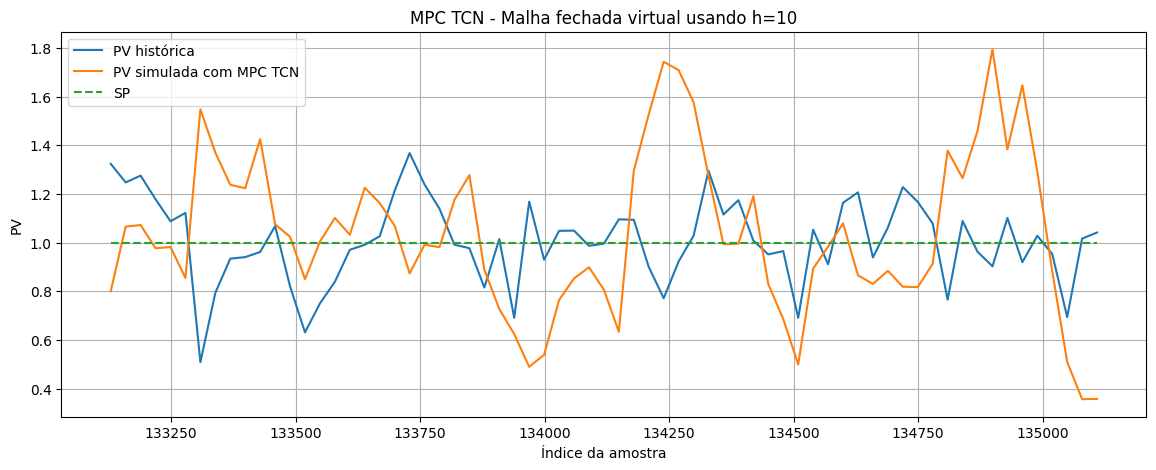

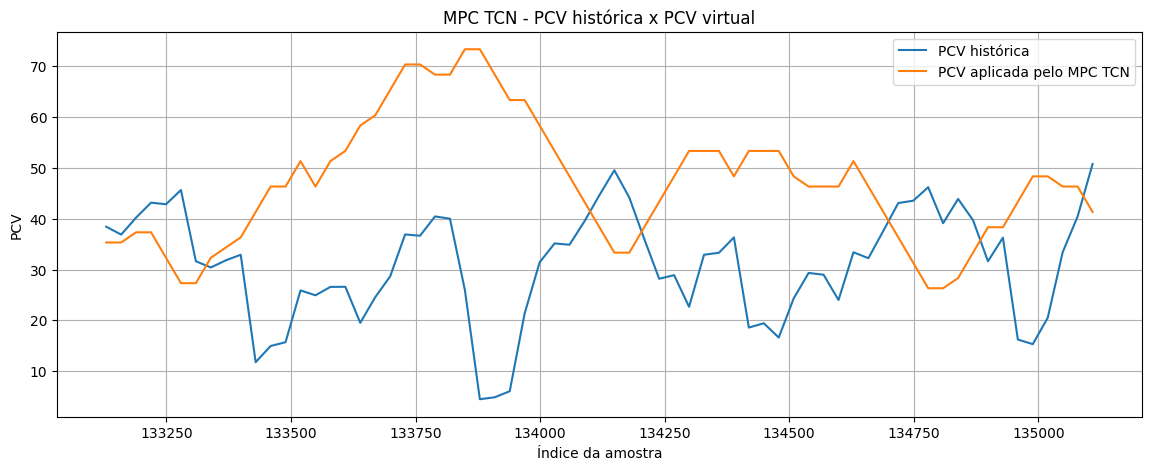

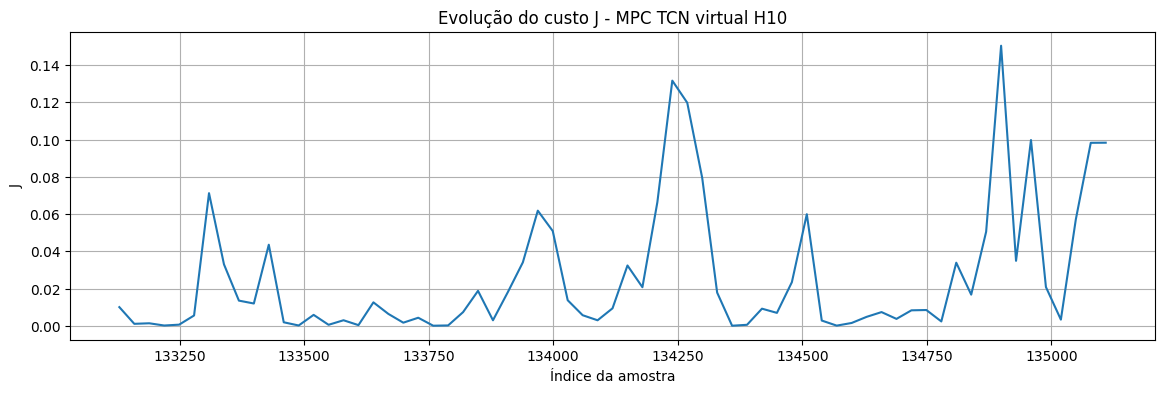

In [82]:
# ============================================================
# 5) EXECUÇÃO
# ============================================================

if MODO_MPC_TCN == "shadow":
    resultado_mpc_tcn = rodar_mpc_tcn_shadow()

elif MODO_MPC_TCN == "closed_loop_virtual_H10":
    resultado_mpc_tcn = rodar_mpc_tcn_closed_loop_H10()

else:
    raise ValueError("MODO_MPC_TCN deve ser 'shadow' ou 'closed_loop_virtual_H10'")

In [ ]:

# ============================================================
# 9) EXPORTAÇÃO SIMPLES DE RESULTADOS
# ============================================================

df_resultados = pd.DataFrame()

for i, h in enumerate(HORIZONTES):
    df_resultados[f"PV_real_h{h}"] = y_test_real[:, i]
    df_resultados[f"PV_prevista_h{h}"] = y_pred_test[:, i]
    df_resultados[f"erro_h{h}"] = y_pred_test[:, i] - y_test_real[:, i]

df_resultados["idx_k"] = idx_test

arquivo_saida = "resultados_tcn_narx_multihorizonte_h1_h5_h10.xlsx"

with pd.ExcelWriter(arquivo_saida, engine="openpyxl") as writer:
    df_metricas.to_excel(writer, sheet_name="metricas", index=False)
    df_resultados.to_excel(writer, sheet_name="previsoes_teste", index=False)

print("\nArquivo exportado:", arquivo_saida)

try:
    from google.colab import files
    files.download(arquivo_saida)
except Exception:
    pass

In [10]:
def testar_sinal_tcn_em_varias_janelas(n_testes=50, delta_mv=10):
    resultados = []

    indices = np.linspace(0, len(idx_test)-1, n_testes).astype(int)

    for ii in indices:
        k_base = int(idx_test[ii])

        janela_past = df.loc[
            k_base - WINDOW + 1:k_base,
            COL_PAST
        ].values.astype(float)

        plano_future = df.loc[
            k_base + 1:k_base + H_MAX,
            COL_FUTURE
        ].values.astype(float)

        u_atual = float(df.loc[k_base, COL_MV])

        plano_menos = plano_future.copy()
        plano_mais = plano_future.copy()

        plano_menos[:, idx_mv_future] = u_atual - delta_mv
        plano_mais[:, idx_mv_future] = u_atual + delta_mv

        y_menos = prever_tcn_multihorizonte(janela_past, plano_menos)
        y_mais = prever_tcn_multihorizonte(janela_past, plano_mais)

        # Para sua física: MV maior deveria gerar PV menor.
        # Logo, y_mais - y_menos deveria ser negativo.
        dif = y_mais - y_menos

        resultados.append({
            "k": k_base,
            "u_atual": u_atual,
            "dif_h1": dif[0],
            "dif_h5": dif[1],
            "dif_h10": dif[2]
        })

    df_sinal = pd.DataFrame(resultados)

    print("Média de diferença: PV(MV+delta) - PV(MV-delta)")
    print(df_sinal[["dif_h1", "dif_h5", "dif_h10"]].mean())

    print("\nPercentual com sinal físico correto, isto é, diferença < 0:")
    print((df_sinal[["dif_h1", "dif_h5", "dif_h10"]] < 0).mean() * 100)

    return df_sinal

df_sinal_tcn = testar_sinal_tcn_em_varias_janelas(n_testes=50, delta_mv=10)
display(df_sinal_tcn.head())

Média de diferença: PV(MV+delta) - PV(MV-delta)
dif_h1     0.028410
dif_h5     0.038689
dif_h10    0.033492
dtype: float32

Percentual com sinal físico correto, isto é, diferença < 0:
dif_h1      2.0
dif_h5      8.0
dif_h10    14.0
dtype: float64


,k,u_atual,dif_h1,dif_h5,dif_h10
0,133094,30.4372,0.020993,0.051556,0.077792
1,133573,31.3441,0.017497,0.034598,0.037118
2,134052,34.2780,-0.003828,0.029445,0.055374
3,134531,30.0063,0.004886,-0.001430,-0.009943
4,135010,20.3430,0.014452,-0.025622,-0.071997
